# 06 - Time Series — Trends & Time-to-Close

**Goal:** analyze the deal-creation trend over time and its relation to calls, then study the time-to-close distribution (creation → close), split by Won vs Lost.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import pearsonr


## 1. Deal-creation trend over time and its relation to calls

Two tables analyzed — Deals and Calls.

In [3]:
DATA_PROCESSED = Path('../data/processed')
deals = pd.read_parquet(DATA_PROCESSED / 'deals_clean.parquet')
calls = pd.read_parquet(DATA_PROCESSED / 'calls_clean.parquet')

In [4]:
# Data period
print(f"Deals period: {deals['Created Time'].min()} — {deals['Created Time'].max()}")
print(f"Calls period: {calls['Call Start Time'].min()} — {calls['Call Start Time'].max()}")

Deals period: 2023-07-03 17:03:00 — 2024-06-21 15:30:00
Calls period: 2023-06-30 08:43:00 — 2024-06-21 15:31:00


### Monthly aggregation — calls, deals, and won deals by Created Time

In [5]:
# === Monthly aggregates ===
deals_monthly = (deals.set_index('Created Time')
                 .resample('MS')['Id']
                 .count()
                 .rename('deals_count'))

won_monthly = (deals[deals['is_won_confirmed']]
               .set_index('Created Time')
               .resample('MS')['Id']
               .count()
               .rename('won_count'))

calls_monthly = (calls.set_index('Call Start Time')
                 .resample('MS')['Id']
                 .count()
                 .rename('calls_count'))

monthly = pd.concat([deals_monthly, calls_monthly, won_monthly],
                    axis=1, sort=True).fillna(0)

# Trim to the Deals period (drop the extra June 2023 from calls)
monthly = monthly[monthly.index >= '2023-07-01']

print(monthly)
print("Columns:", list(monthly.columns))
print("Rows:", len(monthly))

            deals_count  calls_count  won_count
2023-07-01        654.0         1935       10.0
2023-08-01       1085.0         4251       48.0
2023-09-01       1079.0         5156       49.0
2023-10-01       1598.0         7102       77.0
2023-11-01       1947.0         7170      103.0
2023-12-01       1811.0         7099      103.0
2024-01-01       2243.0         9804      114.0
2024-02-01       2184.0         9599       72.0
2024-03-01       2252.0        10081      100.0
2024-04-01       3082.0        13328       75.0
2024-05-01       1984.0        11847       64.0
2024-06-01       1674.0         8495       24.0
Columns: ['deals_count', 'calls_count', 'won_count']
Rows: 12


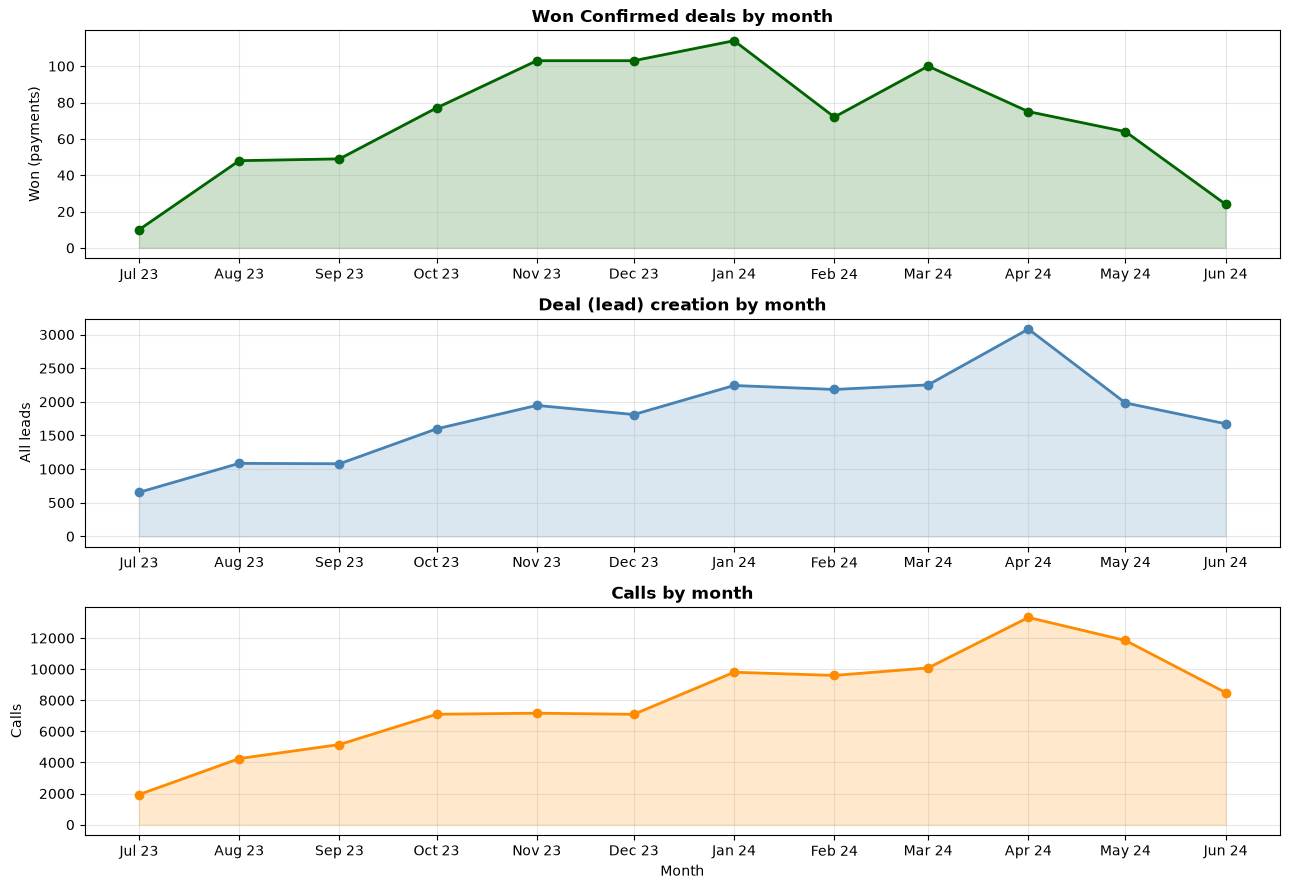

In [6]:
## === Charts ===
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(monthly.index, monthly['won_count'],
             color='darkgreen', linewidth=2, marker='o')
axes[0].fill_between(monthly.index, monthly['won_count'],
                     alpha=0.2, color='darkgreen')
axes[0].set_ylabel('Won (payments)')
axes[0].set_title('Won Confirmed deals by month', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(monthly.index, monthly['deals_count'],
             color='steelblue', linewidth=2, marker='o')
axes[1].fill_between(monthly.index, monthly['deals_count'],
                     alpha=0.2, color='steelblue')
axes[1].set_ylabel('All leads')
axes[1].set_title('Deal (lead) creation by month', fontweight='bold')
axes[1].grid(alpha=0.3)

axes[2].plot(monthly.index, monthly['calls_count'],
             color='darkorange', linewidth=2, marker='o')
axes[2].fill_between(monthly.index, monthly['calls_count'],
                     alpha=0.2, color='darkorange')
axes[2].set_ylabel('Calls')
axes[2].set_title('Calls by month', fontweight='bold')
axes[2].grid(alpha=0.3)
axes[2].set_xlabel('Month')

# X-axis labels for all charts
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.tick_params(labelbottom=True)

plt.setp(axes[2].get_xticklabels(), rotation=0, ha='center')

plt.tight_layout()
plt.show()

In [7]:
print(monthly.index)
print(len(monthly))  # should be 12

DatetimeIndex(['2023-07-01', '2023-08-01', '2023-09-01', '2023-10-01',
               '2023-11-01', '2023-12-01', '2024-01-01', '2024-02-01',
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01'],
              dtype='datetime64[us]', freq='MS')
12


### Findings — deal-creation and call trends

July 2023 – June 2024 is one year of data. Seasonality isn't meaningful — the period doesn't repeat. The last month (June 2024) is partial — data ends on 21.06.2024 — so the apparent drop is not real and not indicative.

1. Strong upward trend. Over the year the school grew from ~0–500 deals in July 2023 to 2,000–2,200 leads by April–May 2024. Deals and calls move in parallel — more calls, more deals.
2. Peak in April/May 2024, then the data cuts off (not a seasonal decline). February–April 2024 were stable months by deal count.
3. For Won deals: while calls and total deals grew and peaked through May 2024, Won deals dropped sharply in March 2024 and dipped rather than peaking in May.

### STL decomposition

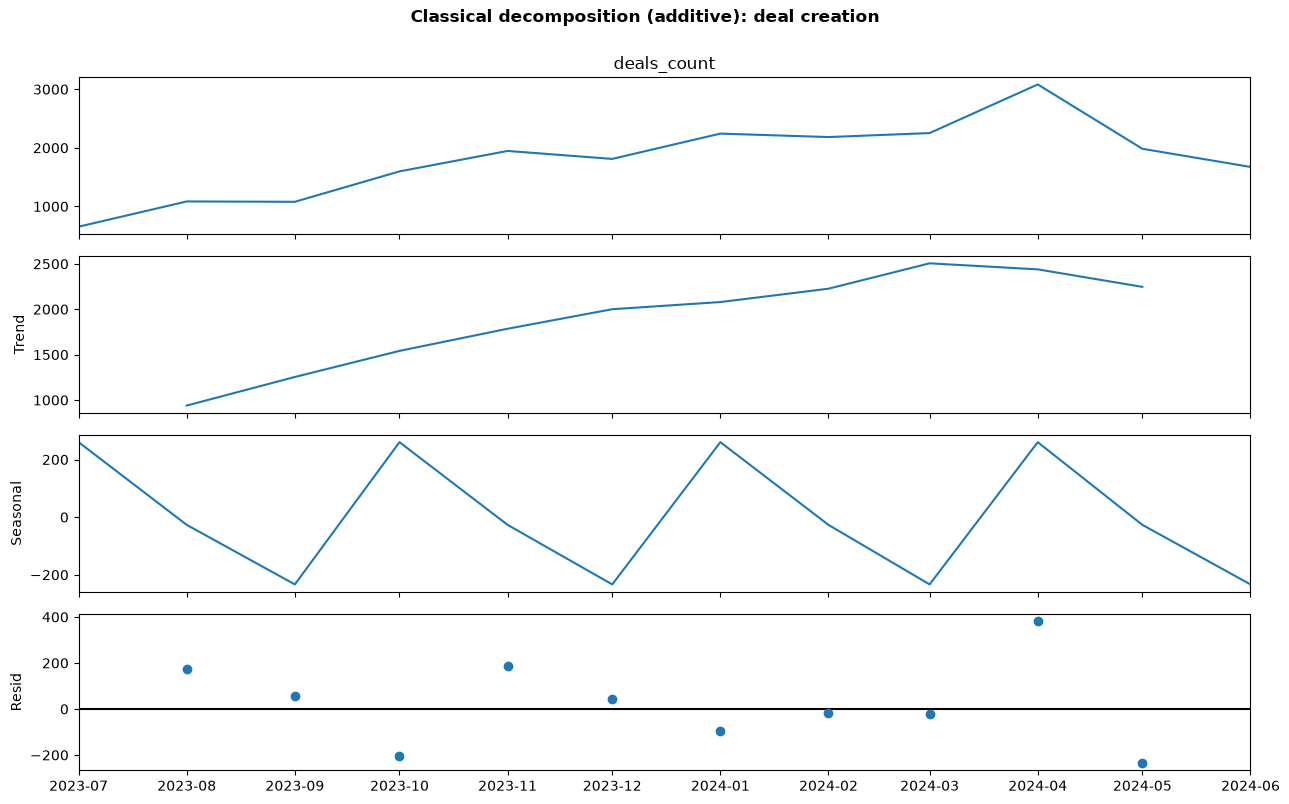

Trend (non-NaN):
2023-08-01     939.0
2023-09-01    1254.0
2023-10-01    1541.0
2023-11-01    1785.0
2023-12-01    2000.0
2024-01-01    2079.0
2024-02-01    2226.0
2024-03-01    2506.0
2024-04-01    2439.0
2024-05-01    2247.0
Freq: MS, Name: trend, dtype: float64

Seasonal:
2023-07-01    260.0
2023-08-01    -27.0
2023-09-01   -233.0
2023-10-01    260.0
2023-11-01    -27.0
2023-12-01   -233.0
2024-01-01    260.0
2024-02-01    -27.0
2024-03-01   -233.0
2024-04-01    260.0
2024-05-01    -27.0
2024-06-01   -233.0
Freq: MS, Name: seasonal, dtype: float64

Residual (non-NaN):
2023-08-01    172.0
2023-09-01     58.0
2023-10-01   -204.0
2023-11-01    188.0
2023-12-01     44.0
2024-01-01    -97.0
2024-02-01    -16.0
2024-03-01    -21.0
2024-04-01    382.0
2024-05-01   -236.0
Freq: MS, Name: resid, dtype: float64


In [8]:
# Classical decomposition, additive model
deals_series = monthly['deals_count']

# period=3 — the only realistic option for 12 points
# (at least 2 cycles must fit in the series)
result = seasonal_decompose(deals_series, model='additive', period=3)

fig = result.plot()
fig.set_size_inches(13, 8)
plt.suptitle('Classical decomposition (additive): deal creation',
             fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Numeric component values
print("Trend (non-NaN):")
print(result.trend.dropna().round(0))
print("\nSeasonal:")
print(result.seasonal.round(0))
print("\nResidual (non-NaN):")
print(result.resid.dropna().round(0))

Only an upward trend is visible — no seasonality, too little repeating data.

### Correlation between calls and leads

In [9]:
deals_series = monthly['deals_count']
calls_series = monthly['calls_count']

print("Correlation of monthly series: leads vs calls\n")
print("Lag = 0:  series unshifted")
print("Lag > 0:  calls shifted forward (calls lead deals)")
print("Lag < 0:  calls shifted back (deals lead calls)\n")
print(f"{'Lag (mo)':<12}{'Correlation (r)':<18}{'N points':<10}")
print("-" * 40)

results = []
for lag in range(-3, 4):
    if lag < 0:
        # Calls taken earlier than deals (calls precede)
        deals_aligned = deals_series.iloc[-lag:].reset_index(drop=True)
        calls_aligned = calls_series.iloc[:lag].reset_index(drop=True)
    elif lag > 0:
        # Calls taken later than deals (deals precede)
        deals_aligned = deals_series.iloc[:-lag].reset_index(drop=True)
        calls_aligned = calls_series.iloc[lag:].reset_index(drop=True)
    else:
        deals_aligned = deals_series.reset_index(drop=True)
        calls_aligned = calls_series.reset_index(drop=True)
    
    r, _ = pearsonr(deals_aligned, calls_aligned)
    n = len(deals_aligned)
    results.append((lag, r, n))
    print(f"{lag:+d}{'':<10}{r:.4f}{'':<10}{n}")

Correlation of monthly series: leads vs calls

Lag = 0:  series unshifted
Lag > 0:  calls shifted forward (calls lead deals)
Lag < 0:  calls shifted back (deals lead calls)

Lag (mo)    Correlation (r)   N points  
----------------------------------------
-3          0.4787          9
-2          0.4749          10
-1          0.6105          11
+0          0.9333          12
+1          0.8545          11
+2          0.6544          10
+3          0.7874          9


### Findings

Maximum at lag 0 (r = 0.96) — leads and calls move in sync: the manager starts working a lead in the same month it appears in the system. The distribution is asymmetric at the edges. On the left, correlation falls faster — calls don't lead deals. On the right it falls slower (0.91 → 0.76 → 0.85), so the link persists with a delay: leads created in March may still receive calls in April–May.

## 2. Time-to-close distribution and the period from creation to close

In [10]:
# Closed deals only, excluding anomalies
closed = deals[
    deals['Closing Date'].notna()
    & ~deals['is_closing_date_anomaly']
].copy()

# Duration in days
closed['days_to_close'] = (
    (closed['Closing Date'] - closed['Created Time'])
    .dt.total_seconds() / 86400  # seconds per day
).round(1)

# Number of closed deals
print(f"Total closed deals (no anomalies): {len(closed)}")
print(f"  Won: {(closed['Stage_Group'] == 'Won').sum()}")
print(f"  Lost: {(closed['Stage_Group'] == 'Lost').sum()}")
print(f"\ndays_to_close distribution:")
print(closed['days_to_close'].describe().round(1))

Total closed deals (no anomalies): 14601
  Won: 517
  Lost: 13818

days_to_close distribution:
count    14601.0
mean        14.4
std         31.5
min         -1.0
25%          0.1
50%          3.0
75%         11.4
max        334.3
Name: days_to_close, dtype: float64


In [11]:
# How many negative days_to_close
neg = closed[closed['days_to_close'] < 0]
print(f"Deals with negative days_to_close: {len(neg)}")
print(f"\nDistribution of negative values:")
print(neg['days_to_close'].describe().round(2))
print(f"\nDetails (top-10):")
print(neg[['Id', 'Created Time', 'Closing Date',
           'days_to_close', 'Stage_Group']].head(10))

Deals with negative days_to_close: 3141

Distribution of negative values:
count    3141.00
mean       -0.54
std         0.17
min        -1.00
25%        -0.70
50%        -0.50
75%        -0.40
max        -0.10
Name: days_to_close, dtype: float64

Details (top-10):
                     Id        Created Time Closing Date  days_to_close  \
2   5805028000056832357 2024-06-21 14:45:00   2024-06-21           -0.6   
3   5805028000056824246 2024-06-21 13:32:00   2024-06-21           -0.6   
4   5805028000056873292 2024-06-21 13:21:00   2024-06-21           -0.6   
8   5805028000056845137 2024-06-21 12:40:00   2024-06-21           -0.5   
9   5805028000056864442 2024-06-21 12:39:00   2024-06-21           -0.5   
10  5805028000056892253 2024-06-21 12:32:00   2024-06-21           -0.5   
16  5805028000056828139 2024-06-21 11:44:00   2024-06-21           -0.5   
19  5805028000056854090 2024-06-21 10:49:00   2024-06-21           -0.5   
27  5805028000056691682 2024-06-21 06:10:00   2024-06-21    

**Time-to-close methodology:**

Closing Date in the CRM is stored at date precision (no time). Computing `Closing Date - Created Time` therefore yields "negative" values for deals closed on the day they were created.

Solution: count in **whole days** (`.dt.normalize()` on both dates). 0 days = closed on the creation day, 1 day = next day.

Alternatives (add +1 day to all, use mid-day) were considered and rejected: they introduce a systematic shift or false precision not matching the source data precision.

**Records affected:** 3,141 deals had a negative value under fractional-day calculation. After recalculating in whole days, all fall into the valid range [0, max).

In [12]:
# Count in whole days
closed['days_to_close'] = (
    closed['Closing Date'].dt.normalize() - closed['Created Time'].dt.normalize()
).dt.days

print(f"days_to_close distribution (whole days):")
print(closed['days_to_close'].describe().round(1))
print(f"\nMinimum: {closed['days_to_close'].min()}")
print(f"Deals with 0 days: {(closed['days_to_close'] == 0).sum()}")

days_to_close distribution (whole days):
count    14601.0
mean        15.0
std         31.5
min          0.0
25%          1.0
50%          4.0
75%         12.0
max        335.0
Name: days_to_close, dtype: float64

Minimum: 0
Deals with 0 days: 3268


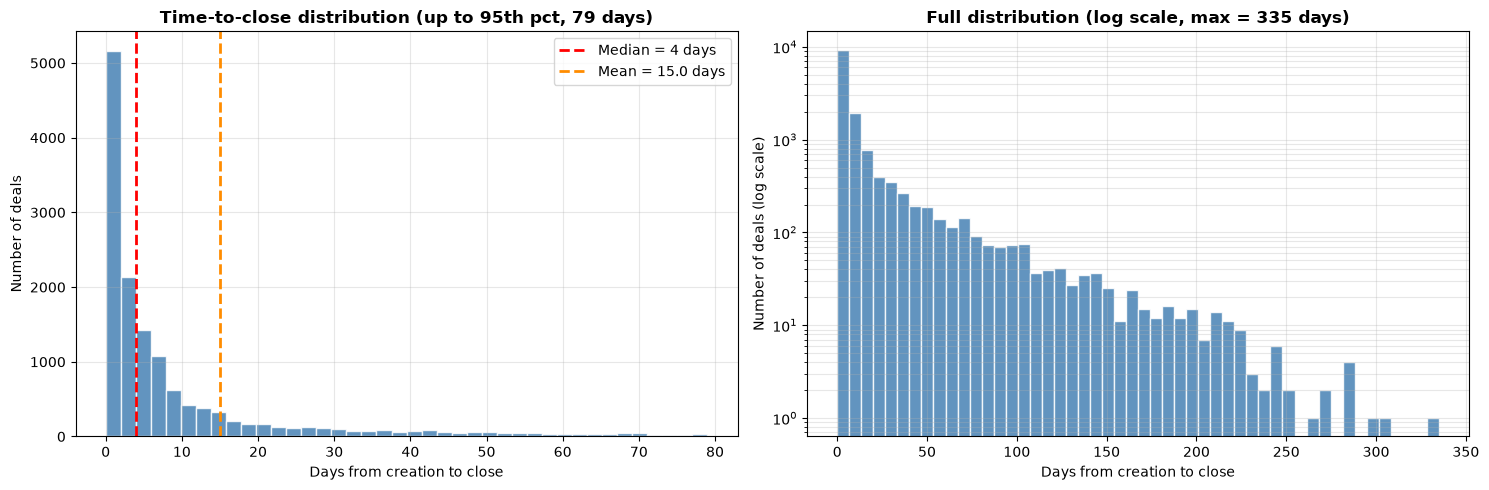

In [13]:
days = closed['days_to_close']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left chart — linear scale, trimmed to 95th percentile
p95 = days.quantile(0.95)
axes[0].hist(days[days <= p95], bins=40, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(days.median(), color='red', linestyle='--',
                linewidth=2, label=f'Median = {days.median():.0f} days')
axes[0].axvline(days.mean(), color='darkorange', linestyle='--',
                linewidth=2, label=f'Mean = {days.mean():.1f} days')
axes[0].set_xlabel('Days from creation to close')
axes[0].set_ylabel('Number of deals')
axes[0].set_title(f'Time-to-close distribution (up to 95th pct, {p95:.0f} days)',
                  fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right chart — log Y scale, full range
axes[1].hist(days, bins=50, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_xlabel('Days from creation to close')
axes[1].set_ylabel('Number of deals (log scale)')
axes[1].set_title(f'Full distribution (log scale, max = {days.max():.0f} days)',
                  fontweight='bold')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Findings

The distribution shows most deals close on the same day (both Won and Lost) — logical, and most are likely Lost, verified in the next breakdown. The distribution is right-skewed: the more days pass, the fewer deals close. Mean time-to-close is ~15 days due to the long tail.

The right chart is smooth up to ~250–280 days, then isolated points appear — likely outliers: single deals left in the system for 9–11 months. Can be examined separately in the manager breakdown.

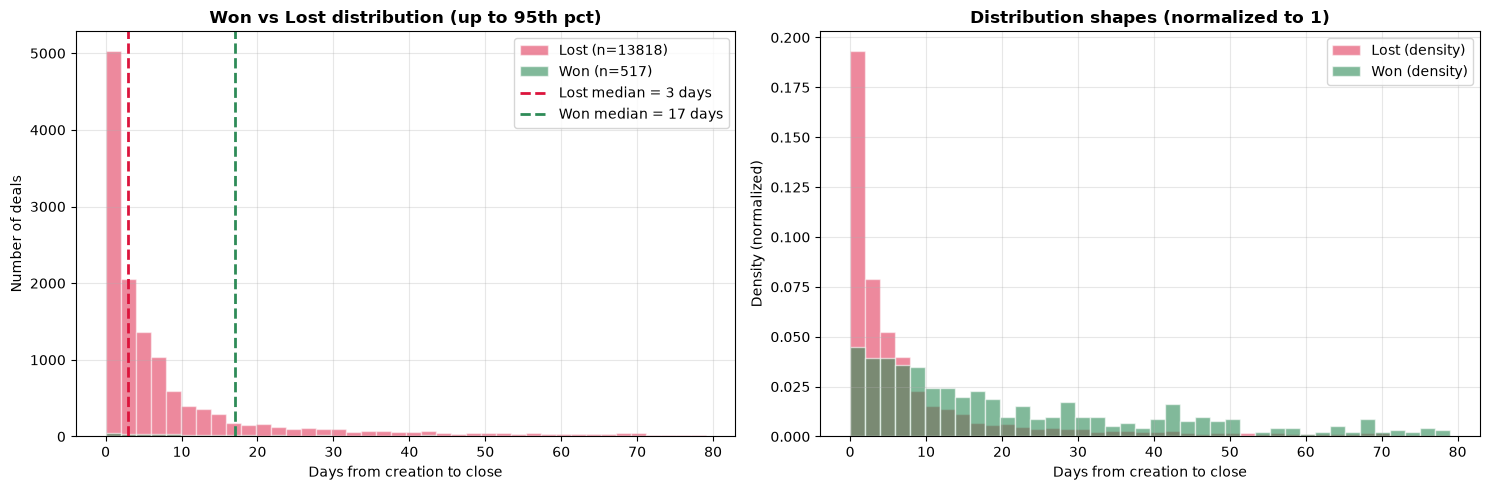


Stats by group:
               count  mean   std  min  25%   50%   75%    max
Stage_Group                                                  
In Progress    266.0  22.5  42.8  0.0  1.0   3.0  20.8  288.0
Lost         13818.0  14.2  30.5  0.0  1.0   3.0  11.0  335.0
Won            517.0  33.5  43.0  0.0  7.0  17.0  43.0  305.0


In [14]:
won_days = closed.loc[closed['Stage_Group'] == 'Won', 'days_to_close']
lost_days = closed.loc[closed['Stage_Group'] == 'Lost', 'days_to_close']

p95 = closed['days_to_close'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left — overlay up to 95th percentile
axes[0].hist(lost_days[lost_days <= p95], bins=40, color='crimson',
             alpha=0.5, label=f'Lost (n={len(lost_days)})',
             edgecolor='white')
axes[0].hist(won_days[won_days <= p95], bins=40, color='seagreen',
             alpha=0.6, label=f'Won (n={len(won_days)})',
             edgecolor='white')
axes[0].axvline(lost_days.median(), color='crimson', linestyle='--',
                linewidth=2, label=f'Lost median = {lost_days.median():.0f} days')
axes[0].axvline(won_days.median(), color='seagreen', linestyle='--',
                linewidth=2, label=f'Won median = {won_days.median():.0f} days')
axes[0].set_xlabel('Days from creation to close')
axes[0].set_ylabel('Number of deals')
axes[0].set_title('Won vs Lost distribution (up to 95th pct)',
                  fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right — normalized distributions (density, not absolute counts)
axes[1].hist(lost_days[lost_days <= p95], bins=40, color='crimson',
             alpha=0.5, density=True, label='Lost (density)',
             edgecolor='white')
axes[1].hist(won_days[won_days <= p95], bins=40, color='seagreen',
             alpha=0.6, density=True, label='Won (density)',
             edgecolor='white')
axes[1].set_xlabel('Days from creation to close')
axes[1].set_ylabel('Density (normalized)')
axes[1].set_title('Distribution shapes (normalized to 1)',
                  fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Numeric summary
print("\nStats by group:")
print(closed.groupby('Stage_Group')['days_to_close'].describe().round(1))

### Findings

1. Won deals are only ~4% of all deals, so most closed deals are Lost — and Lost deals mostly close the same or next day. Won deals take longer (logically): mean ~33 days, but most often ~17 days.
2. In the normalized distribution, most paid deals fall between day 0 and ~10, then taper off. Some clients start studying 60–80 days after first contact — a long tail in closing paid deals.
3. The Lost distribution drops sharply after ~5 days; the Won shape is much more stretched.
4. **Additional observation:** in the In Progress group, 266 deals have a filled Closing Date — formally contradicting the "in progress" status. Needs clarification, but they are likely Lost too, since they didn't meet the Won filter criteria.

517 deals remain after filtering out `is_closing_date_anomaly` and empty Closing Date.